# AkShare 股票数据接口教程

> 基于本项目锁定的 AkShare 版本，收录 **188 个当前可用股票接口**，按投资研究语义组织为 **7 个稳定领域**。
>
> 本 Lab 只学习 `ak.<接口函数>(...)` 的原始调用、参数和返回值，不在这里增加二次封装。
>
> 官方文档：https://akshare.akfamily.xyz/data/stock/stock.html

In [23]:
# === 环境初始化（必须最先运行）===
# AKShare 的部分接口会使用 tqdm.notebook，需要 ipywidgets 提供 IProgress。
try:
    import ipywidgets
except ImportError as exc:
    raise RuntimeError(
        "当前内核缺少 ipywidgets。请在仓库根目录运行 "
        "`uv sync --project labs`，然后重启内核。"
    ) from exc

print(f"环境初始化完成（ipywidgets {ipywidgets.__version__}）")

环境初始化完成（ipywidgets 8.1.8）


---
## 0. 概述

### 学习目标

理解 AKShare 股票接口的函数名、参数、返回字段与上游数据源；用小型、可独立运行的代码单元验证接口，不构建新的数据适配层。

### 安装与验证

```bash
uv sync --project labs
uv run --project labs jupyter lab labs
```

In [24]:
%matplotlib inline
import pandas as pd
import akshare as ak
from requests import RequestException
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager
import mplfinance as mpf

# pandas 3 默认优先使用 pyarrow 字符串；AKShare 1.18.78 的部分正则
# （例如 新闻字段 中的 \\u3000）需要 Python 正则引擎。
pd.options.mode.string_storage = "python"

print('AkShare 版本:', ak.__version__)
print('可用接口数量:', len(dir(ak)))

CHINESE_FONT_CANDIDATES = [
    "Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC",
    "PingFang SC", "Hiragino Sans GB", "WenQuanYi Micro Hei", "Arial Unicode MS",
]
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
CHINESE_FONT = next(
    (name for name in CHINESE_FONT_CANDIDATES if name in installed_fonts),
    None,
)
if CHINESE_FONT is None:
    raise RuntimeError(
        "未找到可显示中文的字体，请安装 Microsoft YaHei、SimHei 或 Noto Sans CJK SC。"
    )

matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [CHINESE_FONT],
    "axes.unicode_minus": False,
    "font.weight": "normal",
})
MPL_CHINESE_STYLE = mpf.make_mpf_style(
    base_mpf_style="yahoo",
    rc={
        "font.family": "Microsoft YaHei",
        "font.sans-serif": ["Microsoft YaHei"],
        "axes.unicode_minus": False,
    },
)
print("Matplotlib 中文字体:", CHINESE_FONT)

AkShare 版本: 1.18.78
可用接口数量: 1149
Matplotlib 中文字体: Microsoft YaHei


### 核心约定

| 参数 | 含义 | 常见取值 |
| --- | --- | --- |
| `symbol` | 标的代码 | 东财 `'600000'`、新浪 `'sh600000'`、雪球 `'SH600000'` |
| `date` | 日期 | `'20241108'`（YYYYMMDD 字符串） |
| `period` | 周期 | `'daily'` / `'weekly'` / `'monthly'` |
| `adjust` | 复权 | `''` 不复权、`'qfq'` 前复权、`'hfq'` 后复权 |

> **命名规律**：`类别_市场_数据类型_源`，如 `stock_zh_a_hist_em` = 股票·A股·历史K线·东方财富

> **分类边界**：成分股清单归 `universe`；板块自身的行情、估值和资金归 `sector`；个股估值快照归 `market`；分红、回购、解禁与质押归 `corporate_actions`。

### 返回值语义与新鲜度检查

完整清单的状态分两层：**接口可调用**只表示函数没有抛错；**可用性**还会检查返回字段的实际语义和最近数据日期。返回值只停在旧年份的接口标为 `过期`，调用失败标为 `不可用`，不要因为函数仍存在就把它用于当前研究。

例如 `stock_sse_summary` 的返回值是 `项目 × 股票/主板/科创板`，并带有 `报告时间`，它描述交易所市场总体情况，所以归入 `market`，不是个股行情。日期窗口按数据子类区分，具体判定和最近数据日期见 `akshare_api.md` 与 `akshare_stock_api.xlsx`。

> 下方“可用接口汇总”与 `akshare_api.md` 保持一致，只列当前可用接口；过期或不可用接口不再作为教程示例。

---
## 1. `universe`：证券主数据与股票池

回答“市场里有哪些股票”。用于证券主数据、上市状态、行业归属与成分股股票池。

**本教程收录的当前可用接口：10 个**

### 可用接口汇总

| 序号 | 子类 | 接口名称 | 接口函数 | 数据源 | 输入参数 |
| ---: | --- | --- | --- | --- | --- |
| 1 | `constituents` | **板块成份详情**, 部分行业数量大于统计数 | `stock_sector_detail` | 新浪/经济通 | sector |
| 2 | `listing_status` | 股票曾用名-新浪 | `stock_info_change_name` | 新浪 | symbol |
| 3 | `listing_status` | 上海证券交易所暂停/终止上市股票 | `stock_info_sh_delist` | 未识别 | symbol |
| 4 | `listing_status` | 深证证券交易所终止/暂停上市股票 | `stock_info_sz_delist` | 未识别 | symbol |
| 5 | `listing_status` | 深证证券交易所股票名称变更 | `stock_info_sz_change_name` | 未识别 | symbol |
| 6 | `security_master` | **沪深京A股股票代码和简称数据** | `stock_info_a_code_name` | 未识别 | null |
| 7 | `security_master` | 北京证券交易所股票代码和简称数据 | `stock_info_bj_name_code` | 北交所 | null |
| 8 | `security_master` | 上海证券交易所股票代码和简称数据 | `stock_info_sh_name_code` | 未识别 | symbol |
| 9 | `security_master` | 深证证券交易所股票代码和股票简称数据 | `stock_info_sz_name_code` | 未识别 | symbol |
| 10 | `security_master` | A+H 上市公司的代码和名称 | `stock_zh_ah_name` | 腾讯 | null |

### A股代码与简称列表

In [25]:
# 1. 全 A 股代码与简称列表（最常用）
df = ak.stock_info_a_code_name()

print('全A股数量:', len(df))

df.head()

全A股数量: 5536


,code,name
0,000001,平安银行
1,000002,万 科Ａ
2,000006,深振业Ａ
3,000007,全新好
4,000008,神州高铁


### 板块成分详情

In [26]:
# 1. 板块行情
# indicator="新浪行业"; choice of {"新浪行业", "启明星行业", "概念", "地域", "行业"}
df = ak.stock_sector_spot(indicator="行业")

df[["label", "板块", '公司家数']].values.tolist()

[['hangye_ZA01', '农业', 16],
 ['hangye_ZA02', '林业', 3],
 ['hangye_ZA03', '畜牧业', 20],
 ['hangye_ZA04', '渔业', 8],
 ['hangye_ZA05', '农、林、牧、渔服务业', 2],
 ['hangye_ZB06', '煤炭开采和洗选业', 25],
 ['hangye_ZB07', '石油和天然气开采业', 8],
 ['hangye_ZB08', '黑色金属矿采选业', 7],
 ['hangye_ZB09', '有色金属矿采选业', 27],
 ['hangye_ZB10', '非金属矿采选业', 2],
 ['hangye_ZB11', '开采辅助活动', 16],
 ['hangye_ZC13', '农副食品加工业', 65],
 ['hangye_ZC14', '食品制造业', 78],
 ['hangye_ZC15', '酒、饮料和精制茶制造业', 51],
 ['hangye_ZC17', '纺织业', 50],
 ['hangye_ZC18', '纺织服装、服饰业', 39],
 ['hangye_ZC19', '皮革、毛皮、羽毛及其制品和制鞋业', 13],
 ['hangye_ZC20', '木材加工和木、竹、藤、棕、草制品业', 9],
 ['hangye_ZC21', '家具制造业', 31],
 ['hangye_ZC22', '造纸和纸制品业', 46],
 ['hangye_ZC23', '印刷和记录媒介复制业', 15],
 ['hangye_ZC24', '文教、工美、体育和娱乐用品制造业', 27],
 ['hangye_ZC25', '石油加工、炼焦和核燃料加工业', 18],
 ['hangye_ZC26', '化学原料和化学制品制造业', 100],
 ['hangye_ZC27', '医药制造业', 100],
 ['hangye_ZC28', '化学纤维制造业', 32],
 ['hangye_ZC29', '橡胶和塑料制品业', 100],
 ['hangye_ZC30', '非金属矿物制品业', 100],
 ['hangye_ZC31', '黑色金属冶炼和压延加工业', 33],
 ['hangye_ZC3

In [27]:
# 2. 板块行情-成份详情
# 通过 ak.stock_sector_spot 返回数据的 label 字段选择 sector

df = ak.stock_sector_detail(sector="hangye_ZB07")

df

100%|██████████| 1/1 [00:00<00:00,  9.25it/s]


,symbol,code,name,trade,pricechange,changepercent,buy,sell,settlement,open,high,low,volume,amount,ticktime,per,pb,mktcap,nmc,turnoverratio
0,sh600028,600028,中国石化,5.10,-0.18,-3.409,5.10,5.11,5.28,5.26,5.27,5.08,333248951,1713349653,15:34:59,19.466,0.740,6.167201e+07,4.832376e+07,0.35170
1,sh600256,600256,广汇能源,5.39,-0.02,-0.370,5.39,5.40,5.41,5.42,5.47,5.35,92684871,501316324,15:34:59,26.014,1.411,3.445290e+06,3.445290e+06,1.45001
2,sh600759,600759,ST洲际,2.37,0.02,0.851,2.36,2.37,2.35,2.36,2.38,2.34,112941316,266491793,15:34:59,64.932,1.082,9.833152e+05,9.820535e+05,2.72562
3,sh600777,600777,新潮能源,4.23,0.01,0.237,4.23,4.24,4.22,4.23,4.29,4.22,23003371,97752389,15:34:59,23.500,1.297,2.876610e+06,2.692882e+06,0.36134
4,sh600938,600938,中国海油,31.56,-0.29,-0.911,31.56,31.57,31.85,31.81,32.00,31.55,38155475,1210275208,15:34:59,12.280,1.792,1.500045e+08,9.436440e+06,1.27610
5,sh601857,601857,中国石油,10.86,-0.19,-1.719,10.86,10.87,11.05,10.98,11.02,10.83,129541459,1409900468,15:34:59,12.628,1.223,1.987608e+08,1.758474e+08,0.08000
6,sz000968,000968,蓝焰控股,7.04,0.04,0.571,7.03,7.04,7.00,7.00,7.09,6.94,23734797,166695141,16:23:45,20.114,1.065,6.811219e+05,6.811219e+05,2.45320
7,sz300483,300483,首华燃气,21.86,-0.38,-1.709,21.86,21.87,22.24,22.22,22.48,21.73,11196086,246664738,16:23:45,35.258,2.295,8.418455e+05,8.412553e+05,2.90930


---
## 2. `market`：行情与估值快照

回答“价格发生了什么”。涵盖市场概况、实时/历史行情、分时数据与估值快照。

**本教程收录的当前可用接口：19 个**

### 可用接口汇总

| 序号 | 子类 | 接口名称 | 接口函数 | 数据源 | 输入参数 |
| ---: | --- | --- | --- | --- | --- |
| 1 | `daily` | 上海证券交易所每日股票情况 | `stock_sse_deal_daily` | 上交所 | date |
| 2 | `daily` | **A股历史行情数据-新浪**; | `stock_zh_a_daily` | 未识别 | symbol, start_date, end_date, adjust, timeout |
| 3 | `daily` | **A股历史行情数据-腾讯** | `stock_zh_a_hist_tx` | 腾讯 | symbol, start_date, end_date, adjust, timeout |
| 4 | `snapshot` | **A股实时行情数据-新浪**, 重复运行本函数会被新浪暂时封 IP, 建议增加时间间隔 | `stock_zh_a_spot` | 新浪 | null |
| 5 | `snapshot` | 港股实时行情数据-新浪 | `stock_hk_spot` | 新浪 | null |
| 6 | `snapshot` | 科创板实时行情数据-新浪 | `stock_zh_kcb_spot` | 新浪 | null |
| 7 | `snapshot` | A股新股实时行情数据-东方财富 | `stock_new_a_spot_em` | 东方财富 | null |
| 8 | `snapshot` | A股次新股实时行情数据-新浪 | `stock_zh_a_new` | 新浪 | null |
| 9 | `snapshot` | A+H股实时行情数据-腾讯 | `stock_zh_ah_spot` | 腾讯 | null |
| 10 | `snapshot` | B股实时行情数据-新浪 | `stock_zh_b_spot` | 新浪 |  |
| 11 | `snapshot` | 上海证券交易所-股票数据总貌 | `stock_sse_summary` | 上交所 | null |
| 12 | `snapshot` | 深圳证券交易所-市场总貌-地区交易排序 | `stock_szse_area_summary` | 深交所 | date |
| 13 | `snapshot` | 深圳证券交易所-市场总貌-证券类别统计 | `stock_szse_summary` | 深交所 | date |
| 14 | `valuation` | A股破净股统计数据 | `stock_a_below_net_asset_statistics` | 上交所/经济通 | symbol |
| 15 | `valuation` | 指数市净率 | `stock_index_pb_lg` | 乐估乐股 | symbol |
| 16 | `valuation` | 指数市盈率 | `stock_index_pe_lg` | 乐估乐股 | symbol |
| 17 | `valuation` | 主板市净率 | `stock_market_pb_lg` | 乐估乐股/经济通 | symbol |
| 18 | `valuation` | 主板市盈率 | `stock_market_pe_lg` | 乐估乐股/经济通 | symbol |
| 19 | `valuation` | 估值分析 | `stock_value_em` | 东方财富 | symbol |

### A股历史日K线

In [28]:
# 1. A股历史日K线（新浪，symbol需带前缀）
df = ak.stock_zh_a_daily(symbol="sz000002", start_date="20260701", end_date="20260724", adjust="qfq")
print('历史K线:', df.shape)

df.tail()

历史K线: (18, 9)


,date,open,high,low,close,volume,amount,outstanding_share,turnover
13,2026-07-20,3.09,3.17,3.07,3.15,161553609.0,505119123.0,9.716936e+09,0.016626
14,2026-07-21,3.12,3.17,3.10,3.13,138402993.0,432657761.0,9.716936e+09,0.014243
15,2026-07-22,3.11,3.22,3.09,3.19,163572262.0,517044810.0,9.716936e+09,0.016834
16,2026-07-23,3.16,3.17,3.10,3.17,112395903.0,352557747.0,9.716936e+09,0.011567
17,2026-07-24,3.14,3.17,3.07,3.07,112405079.0,349079945.0,9.716936e+09,0.011568


In [36]:
# 2. A股历史日K线（腾讯）
df = ak.stock_zh_a_hist_tx(
    symbol='000002',
    start_date='20260701',
    end_date='20260724',
    adjust='qfq'  # 前复权
)
print('历史K线:', df.shape)

df.tail()

  0%|          | 0/1 [00:00<?, ?it/s]

历史K线: (18, 8)


,date,open,close,high,low,volume,turnover,amount
13,2026-07-20,3.09,3.15,3.17,3.07,1615536.0,0.0166,505119100.0
14,2026-07-21,3.12,3.13,3.17,3.10,1384030.0,0.0142,432657800.0
15,2026-07-22,3.11,3.19,3.22,3.09,1635723.0,0.0168,517044800.0
16,2026-07-23,3.16,3.17,3.17,3.10,1123959.0,0.0116,352557700.0
17,2026-07-24,3.14,3.07,3.17,3.07,1124051.0,0.0116,349079900.0


findfont: Failed to find font weight semibold, now using 700.


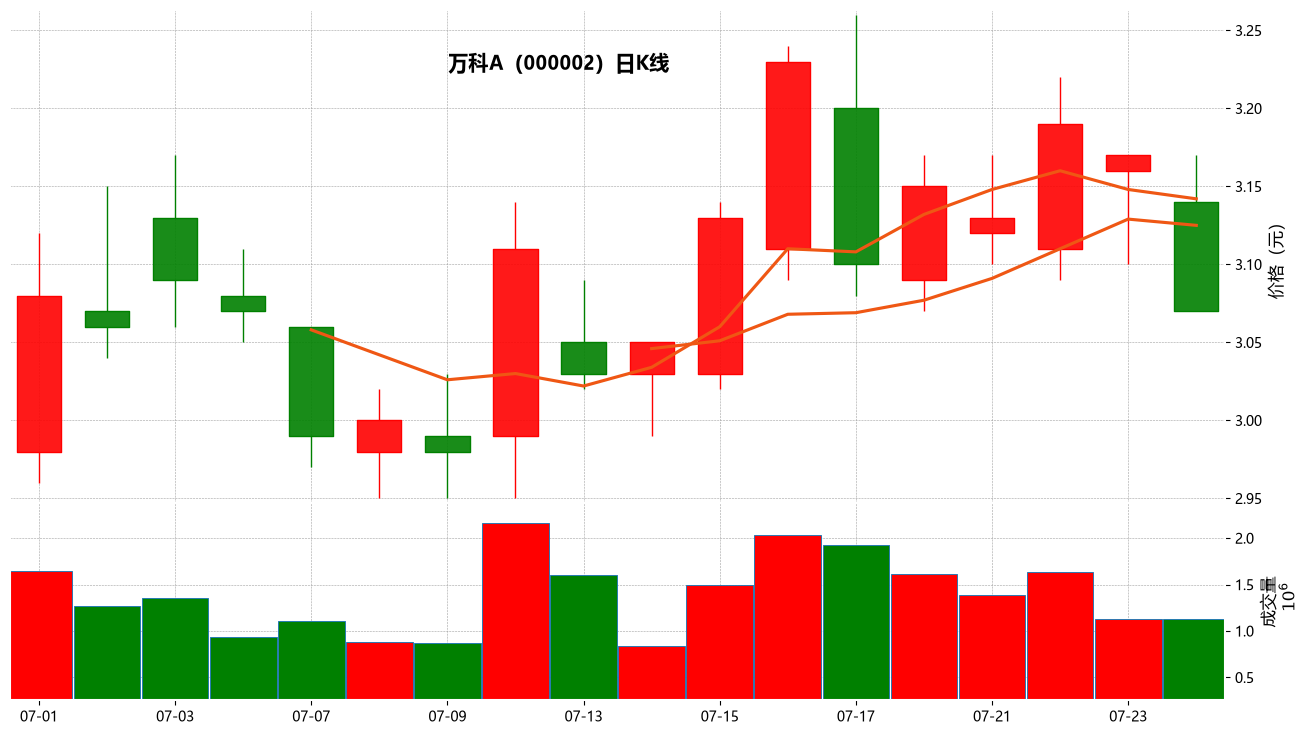

In [37]:
# 1. 复制数据，避免反复执行 Notebook 时修改原始 df
plot_df = df.copy()

# 2. 腾讯接口返回的是英文小写字段
plot_df = plot_df.rename(columns={
    "date": "Date",
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "volume": "Volume",
})

# 3. 日期必须成为 DatetimeIndex
plot_df["Date"] = pd.to_datetime(plot_df["Date"])
plot_df = plot_df.set_index("Date").sort_index()

# 4. 保证 OHLCV 是数值
price_columns = ["Open", "High", "Low", "Close", "Volume"]
plot_df[price_columns] = plot_df[price_columns].apply(
    pd.to_numeric,
    errors="coerce",
)

plot_df = plot_df.dropna(subset=["Open", "High", "Low", "Close"])

# 5. A股配色：红涨绿跌
market_colors = mpf.make_marketcolors(
    up="red",
    down="green",
    edge="inherit",
    wick="inherit",
    volume="inherit",
)

# 6. 创建支持中文的 mplfinance 样式
cn_style = mpf.make_mpf_style(
    base_mpf_style="charles",
    marketcolors=market_colors,
    rc={
        "font.family": "sans-serif",
        "font.sans-serif": ["Microsoft YaHei"],
        "axes.unicode_minus": False,
        "font.weight": "normal",
        "axes.titleweight": "normal",
        "axes.labelweight": "normal",
    },
)

# 7. 绗制K线
mpf.plot(
    plot_df,
    type="candle",
    volume=True,
    mav=(5, 10),
    title="万科A（000002）日K线",
    ylabel="价格（元）",
    ylabel_lower="成交量",
    style=cn_style,       # 不再写 style="charles"
    figsize=(14, 8),
    datetime_format="%m-%d",
    xrotation=0,
    tight_layout=True,
)

### A股实时行情

In [39]:
# 1. A股实时行情（新浪）
df = ak.stock_zh_a_spot()

print('A股实时行情:', df.shape)

df.head(5)

Please wait for a moment:   0%|          | 0/70 [00:00<?, ?it/s]

A股实时行情: (5535, 14)


,代码,名称,最新价,涨跌额,涨跌幅,买入,卖出,昨收,今开,最高,最低,成交量,成交额,时间戳
0,bj920000,安徽凤凰,14.39,0.20,1.409,14.39,14.40,14.19,13.90,14.39,13.90,1643570.0,23286355.0,15:30:00
1,bj920001,纬达光电,11.68,0.16,1.389,11.68,11.72,11.52,11.48,11.75,11.47,1303798.0,15128998.0,15:30:00
2,bj920002,万达轴承,55.34,1.09,2.009,55.33,55.34,54.25,55.08,55.81,52.43,1618961.0,88058920.0,15:30:00
3,bj920003,中诚咨询,16.70,0.06,0.361,16.65,16.70,16.64,16.64,16.74,16.55,149442.0,2486348.0,15:30:00
4,bj920005,鼎佳精密,24.83,0.54,2.223,24.80,24.83,24.29,24.67,24.85,24.38,307954.0,7595077.0,15:30:00


### 港股实时行情（新浪）

In [40]:
# 2. 港股实时行情（新浪）
df = ak.stock_hk_spot()

print('港股实时行情:', df.shape)

df.head(5)

  0%|          | 0/99 [00:00<?, ?it/s]

港股实时行情: (2806, 16)


,日期时间,代码,中文名称,英文名称,交易类型,最新价,涨跌额,涨跌幅,昨收,今开,最高,最低,成交量,成交额,买一,卖一
0,2026/08/04 16:08:28,00001,长和,CKH HOLDINGS,,74.000,1.000,1.36986,73.00,74.25,74.400,72.650,5970764,441471372,73.90000,74.000
1,2026/08/04 16:08:26,00002,中电控股,CLP HOLDINGS,,76.900,-0.650,-0.83817,77.55,77.60,77.800,76.600,3409539,262686196,76.85000,76.900
2,2026/08/04 16:08:26,00003,香港中华煤气,HK & CHINA GAS,,6.905,-0.055,-0.79023,6.96,7.00,7.005,6.885,17055041,117994486,6.90000,6.905
3,2026/08/04 16:08:20,00004,九龙仓集团,WHARF HOLDINGS,,19.440,-0.060,-0.30769,19.50,19.88,19.880,19.300,455482,8833904,19.43000,19.440
4,2026/08/04 16:08:26,00005,汇丰控股,HSBC HOLDINGS,,166.500,-1.700,-1.01070,168.20,168.40,169.700,164.000,27429003,4592038175,166.39999,166.500


### A股估值（东方财富）

In [41]:
# 3. A股估值指标（东方财富）
df = ak.stock_value_em(symbol='000002')

print('估值指标:', df.shape)

df.tail()

估值指标: (2083, 13)


,数据日期,当日收盘价,当日涨跌幅,总市值,流通市值,总股本,流通股本,PE(TTM),PE(静),市净率,PEG值,市现率,市销率
2078,2026-07-29,3.28,4.126984,3.913273e+10,3.187155e+10,11930709471,9716935865,-0.443368,-0.441896,0.354030,0.003775,14.817286,0.174415
2079,2026-07-30,3.33,1.524390,3.972926e+10,3.235740e+10,11930709471,9716935865,-0.450127,-0.448632,0.359426,0.003833,15.043159,0.177073
2080,2026-07-31,3.34,0.300300,3.984857e+10,3.245457e+10,11930709471,9716935865,-0.451478,-0.449979,0.360506,0.003844,15.088334,0.177605
2081,2026-08-03,3.36,0.598802,4.008718e+10,3.264890e+10,11930709471,9716935865,-0.454182,-0.452674,0.362664,0.003867,15.178683,0.178669
2082,2026-08-04,3.26,-2.976190,3.889411e+10,3.167721e+10,11930709471,9716935865,-0.440664,-0.439201,0.351871,0.003752,14.726937,0.173351


---
## 3. `fundamentals`：公司与财务基本面

回答“这家公司经营得怎么样”。涵盖公司资料、财务三表、指标、股东与聚合预测。

**本教程收录的当前可用接口：23 个**

### 可用接口汇总

| 子类 | 接口中文名称 | 接口 | 数据源 | 参数 |
| --- | --- | --- | --- | --- |
| `business_segments` | 同花顺-主营介绍 | `stock_zyjs_ths` | 同花顺 | symbol |
| `company_profile` | 巨潮资讯-个股-公司概况 | `stock_profile_cninfo` | 巨潮 | symbol |
| `financial_indicators` | 新浪财经-财务报表-关键指标 | `stock_financial_abstract` | 新浪 | symbol |
| `financial_indicators` | 同花顺-财务指标-重要指标；替换 stock_financial_abstract_ths 接口 | `stock_financial_abstract_new_ths` | 同花顺 | symbol, indicator |
| `financial_indicators` | 新浪财经-财务分析-财务指标 | `stock_financial_analysis_indicator` | 新浪 | symbol, start_year |
| `financial_indicators` | 东方财富网-数据中心-特色数据-商誉-A股商誉市场概况 | `stock_sy_profile_em` | 东方财富 | null |
| `financial_statements` | 同花顺-财务指标-利润表；替换 stock_financial_benefit_ths 接口 | `stock_financial_benefit_new_ths` | 同花顺 | symbol, indicator |
| `financial_statements` | 同花顺-财务指标-现金流量表；替换 stock_financial_cash_ths 接口 | `stock_financial_cash_new_ths` | 同花顺 | symbol, indicator |
| `financial_statements` | 同花顺-财务指标-资产负债表；替换 stock_financial_debt_ths 接口 | `stock_financial_debt_new_ths` | 同花顺 | symbol, indicator |
| `financial_statements` | 新浪财经-财务报表-三大报表 | `stock_financial_report_sina` | 新浪 | stock, symbol |
| `forecasts` | 经济通-公司资料-盈利预测 | `stock_hk_profit_forecast_et` | 经济通 | symbol, indicator |
| `forecasts` | 同花顺-盈利预测 | `stock_profit_forecast_ths` | 同花顺 | symbol, indicator |
| `shareholders` | 新浪财经-股东股本-流通股东 | `stock_circulate_stock_holder` | 新浪 | symbol |
| `shareholders` | 新浪财经-股本股东-基金持股 | `stock_fund_stock_holder` | 新浪 | symbol |
| `shareholders` | 东方财富网-数据中心-股东分析-股东持股分析-十大流通股东 | `stock_gdfx_free_holding_analyse_em` | 东方财富 | date |
| `shareholders` | 东方财富网-数据中心-股东分析-股东持股变动统计-十大流通股东 | `stock_gdfx_free_holding_change_em` | 东方财富 | date |
| `shareholders` | 东方财富网-数据中心-股东分析-股东持股明细-十大流通股东 | `stock_gdfx_free_holding_detail_em` | 东方财富/经济通 | date |
| `shareholders` | 东方财富网-数据中心-股东分析-股东持股分析-十大股东 | `stock_gdfx_holding_analyse_em` | 东方财富 | date |
| `shareholders` | 新浪财经-机构持股-机构持股一览表 | `stock_institute_hold` | 新浪 | symbol |
| `shareholders` | 新浪财经-机构持股-机构持股详情 | `stock_institute_hold_detail` | 新浪/经济通 | stock, quarter |
| `shareholders` | 新浪财经-股本股东-主要股东 | `stock_main_stock_holder` | 新浪 | stock |
| `shareholders` | 东方财富网-数据中心-特色数据-股东户数数据 | `stock_zh_a_gdhs` | 未识别 | symbol |
| `shareholders` | 东方财富网-数据中心-特色数据-股东户数详情 | `stock_zh_a_gdhs_detail_em` | 东方财富/经济通 | symbol |

### 资产负债表（同花顺）

In [9]:
# 1. 同花顺资产负债表
df = ak.stock_financial_debt_new_ths(symbol='600000', indicator='按报告期')

print('资产负债表:', df.shape)

df.head(3)

资产负债表: (5950, 10)


,report_date,report_name,report_period,quarter_name,metric_name,value,single,yoy,mom,single_yoy
0,2026-03-31,2026一季报,2026-1,2026一季度,treasury_stock,,,,,
1,2026-03-31,2026一季报,2026-1,2026一季度,productive_biological_assets,,,,,
2,2026-03-31,2026一季报,2026-1,2026一季度,deferred_tax_debt,633000000.0000,,0.01118211,,


### 关键财务指标（新浪）

In [10]:
# 2. 关键财务指标摘要（新浪）
df_abs = ak.stock_financial_abstract(symbol='sh600000')

print('关键指标:', df_abs.shape)

df_abs.head(3)

关键指标: (80, 109)


,选项,指标,20260331,20251231,20250930,20250630,20250331,20241231,20240930,20240630,...,20011231,20010930,20010630,20001231,20000630,19991231,19990630,19981231,19971231,19961231
0,常用指标,归母净利润,1.786100e+10,5.001700e+10,3.881900e+10,2.973700e+10,1.759800e+10,4.525700e+10,3.522300e+10,2.698800e+10,...,1.061878e+09,8.219933e+08,5.349113e+08,7.970330e+08,5.009706e+08,7.291420e+08,5.059709e+08,7.806024e+08,6.449990e+08,6.291110e+08
1,常用指标,营业总收入,4.657300e+10,1.739640e+11,1.322800e+11,9.055900e+10,4.592200e+10,1.707480e+11,1.298390e+11,8.824800e+10,...,5.069861e+09,2.859229e+09,2.198802e+09,3.394839e+09,1.586769e+09,2.783119e+09,9.215270e+08,2.272001e+09,2.264622e+09,1.878030e+09
2,常用指标,营业成本,2.478400e+10,1.203560e+11,9.007300e+10,5.706100e+10,2.575800e+10,1.233050e+11,9.343400e+10,5.802000e+10,...,2.744718e+09,1.747571e+09,1.120534e+09,2.405483e+09,9.117543e+08,1.915320e+09,6.556816e+08,1.956527e+09,1.673194e+09,1.215210e+09


### 股东持股变动统计

In [11]:
# 1. 股东持股变动统计-十大流通股东（按日期）
df = ak.stock_gdfx_free_holding_change_em(date='20260630')

print('十大流通股东变动:', df.shape)

df.head(10)

  0%|          | 0/2 [00:00<?, ?it/s]

十大流通股东变动: (995, 10)


,序号,股东名称,股东类型,期末持股只数统计-总持有,期末持股只数统计-新进,期末持股只数统计-增加,期末持股只数统计-不变,期末持股只数统计-减少,流通市值统计,持有个股
0,1,香港中央结算有限公司,其他,63,5.0,39.0,NaN,19.0,4.330119e+11,"002145|钛能化学,600595|中孚实业,603606|东方电缆,603063|禾望电..."
1,2,高盛国际资产管理公司,QFII,20,15.0,2.0,NaN,3.0,2.425106e+09,"603063|禾望电气,300852|四会富仕,002981|朝阳科技,600641|先导基..."
2,3,UBS AG,QFII,13,12.0,1.0,NaN,NaN,1.162465e+10,"300396|ST迪瑞,600641|先导基电,002592|ST八菱,300508|维宏股..."
3,4,J.P.Morgan Securities PLC-自有资金,QFII,10,7.0,2.0,NaN,1.0,8.890706e+08,"002413|雷科防务,000633|合金投资,301100|风光股份,600711|盛屯矿..."
4,5,高盛公司,QFII,7,4.0,2.0,NaN,1.0,2.118493e+08,"002577|雷柏科技,002413|雷科防务,301100|风光股份,300508|维宏股..."
5,6,中国人寿保险股份有限公司-传统-普通保险产品-005L-CT001沪,保险,6,3.0,3.0,NaN,NaN,7.686872e+09,"002064|华峰化学,300738|奥飞数据,002138|顺络电子,601168|西部矿..."
6,7,Morgan Stanley & Co. International PLC,QFII,6,5.0,1.0,NaN,NaN,1.629941e+08,"600110|诺德股份,603101|汇嘉时代,000633|合金投资,300508|维宏股..."
7,8,招商证券股份有限公司-华夏中证电网设备主题交易型开放式指数证券投资基金,基金,5,NaN,NaN,NaN,5.0,1.456743e+09,"603606|东方电缆,300222|科大智能,002533|金杯电工,001359|平安电..."
8,9,中信证券资产管理(香港)有限公司-客户资金,QFII,5,2.0,NaN,NaN,3.0,5.148343e+08,"603400|华之杰,300463|迈克生物,300671|富满微,002290|禾盛新材,..."
9,10,BARCLAYS BANK PLC,QFII,4,3.0,1.0,NaN,NaN,8.528154e+07,"300508|维宏股份,301100|风光股份,002549|凯美特气,603155|新亚强"


### 流通股东（新浪）

In [12]:
# 3. 流通股东（新浪）
df_holder = ak.stock_circulate_stock_holder(symbol='sh600000')

print('流通股东:')

df_holder.head()

  0%|          | 0/89 [00:00<?, ?it/s]

流通股东:


,截止日期,公告日期,编号,股东名称,持股数量,占流通股比例,股本性质
0,2026-03-31,2026-04-30,1,上海国际集团有限公司,7086834641,21.278,国有股
1,2026-03-31,2026-04-30,2,中国移动通信集团广东有限公司,6053495450,18.175,国有股
2,2026-03-31,2026-04-30,3,富德生命人寿保险股份有限公司-传统,2779437274,8.345,境内法人股
3,2026-03-31,2026-04-30,4,富德生命人寿保险股份有限公司-资本金,1763232325,5.294,境内法人股
4,2026-03-31,2026-04-30,5,中国东方资产管理股份有限公司,1502726171,4.512,国有股


---
## 4. `corporate_actions`：公司行为与股本事件

回答“持有人的权益发生了什么”。涵盖发行、分红、回购、解禁、质押和股本变化。

**本教程收录的当前可用接口：37 个**

### 可用接口汇总

| 子类 | 接口中文名称 | 接口 | 数据源 | 参数 |
| --- | --- | --- | --- | --- |
| `capital_change` | 东方财富网-数据中心-股东大会 | `stock_gddh_em` | 东方财富 | null |
| `capital_change` | 东方财富网-数据中心-特色数据-高管持股 | `stock_ggcg_em` | 东方财富 | symbol |
| `capital_change` | 巨潮资讯-数据中心-专题统计-股东股本-股本变动 | `stock_hold_change_cninfo` | 巨潮 | symbol |
| `capital_change` | 巨潮资讯-数据中心-专题统计-股东股本-高管持股变动明细 | `stock_hold_management_detail_cninfo` | 巨潮/经济通 | symbol |
| `capital_change` | 东方财富网-数据中心-特色数据-高管持股-董监高及相关人员持股变动明细 | `stock_hold_management_detail_em` | 东方财富/经济通 | null |
| `capital_change` | 东方财富-A股数据-股本结构 | `stock_zh_a_gbjg_em` | 东方财富/北交所 | symbol |
| `dividend` | 百度股市通-交易提醒-分红派息 | `news_trade_notify_dividend_baidu` | 百度 | date, cookie |
| `dividend` | 巨潮资讯-个股-历史分红 | `stock_dividend_cninfo` | 巨潮 | symbol |
| `dividend` | 东方财富网-数据中心-分红送配-分红送配详情 | `stock_fhps_detail_em` | 东方财富/经济通 | symbol |
| `dividend` | 同花顺-分红情况 | `stock_fhps_detail_ths` | 同花顺/经济通 | symbol |
| `dividend` | 新浪财经-发行与分配-历史分红 | `stock_history_dividend` | 新浪 | null |
| `dividend` | 新浪财经-发行与分配-分红配股 | `stock_history_dividend_detail` | 新浪/经济通 | symbol, indicator, date |
| `dividend` | 东方财富-港股-核心必读-分红派息 | `stock_hk_dividend_payout_em` | 东方财富 | symbol |
| `issuance` | 东方财富网-数据中心-新股申购-打新收益率 | `stock_dxsyl_em` | 东方财富 | null |
| `issuance` | 东方财富网-数据中心-新股申购-首发申报信息-首发申报企业信息 | `stock_ipo_declare_em` | 东方财富 | null |
| `issuance` | 同花顺-数据中心-新股申购与中签-港股 | `stock_ipo_hk_ths` | 同花顺 | null |
| `issuance` | 新浪财经-发行与分配-新股发行 | `stock_ipo_info` | 新浪 | stock |
| `issuance` | 东方财富网-数据中心-新股申购-新股上会信息 | `stock_ipo_review_em` | 东方财富 | null |
| `issuance` | 巨潮资讯-个股-上市相关 | `stock_ipo_summary_cninfo` | 巨潮 | symbol |
| `issuance` | 东方财富网-数据中心-新股申购-IPO辅导信息 | `stock_ipo_tutor_em` | 东方财富 | null |
| `issuance` | 巨潮资讯-数据中心-新股数据-新股发行 | `stock_new_ipo_cninfo` | 巨潮 | null |
| `issuance` | 东方财富网-数据中心-新股数据-增发-全部增发 | `stock_qbzf_em` | 东方财富 | null |
| `issuance` | 东方财富网-数据中心-新股数据-IPO审核信息-全部 | `stock_register_all_em` | 东方财富 | null |
| `issuance` | 东方财富网-数据中心-新股数据-IPO审核信息-北交所 | `stock_register_bj` | 北交所 | null |
| `issuance` | 东方财富网-数据中心-新股数据-IPO审核信息-创业板 | `stock_register_cyb` | 未识别 | null |
| `issuance` | 东方财富网-数据中心-新股数据-注册制审核-达标企业 | `stock_register_db` | 未识别 | null |
| `issuance` | 东方财富网-数据中心-新股数据-IPO审核信息-科创板 | `stock_register_kcb` | 未识别 | null |
| `issuance` | 东方财富网-数据中心-新股数据-IPO审核信息-上海主板 | `stock_register_sh` | 未识别 | null |
| `issuance` | 东方财富网-数据中心-新股数据-IPO审核信息-深圳主板 | `stock_register_sz` | 未识别 | null |
| `issuance` | 东方财富网-数据中心-新股数据-新股申购-新股申购与中签查询 | `stock_xgsglb_em` | 东方财富 | symbol |
| `issuance` | 同花顺-数据中心-新股数据-新股上市首日 | `stock_xgsr_ths` | 同花顺 | null |
| `pledge` | 巨潮资讯-数据中心-专题统计-公司治理-股权质押 | `stock_cg_equity_mortgage_cninfo` | 巨潮 | date |
| `pledge` | 东方财富网-数据中心-特色数据-股权质押-重要股东股权质押明细 | `stock_gpzy_pledge_ratio_detail_em` | 东方财富/经济通 | null |
| `pledge` | 东方财富网-数据中心-特色数据-股权质押-股权质押市场概况 | `stock_gpzy_profile_em` | 东方财富 | null |
| `repurchase` | 东方财富网-数据中心-股票回购-股票回购数据 | `stock_repurchase_em` | 东方财富 | null |
| `unlock` | 东方财富网-数据中心-限售股解禁-解禁详情一览 | `stock_restricted_release_detail_em` | 东方财富/经济通 | start_date, end_date |
| `unlock` | 东方财富网-数据中心-特色数据-限售股解禁 | `stock_restricted_release_summary_em` | 东方财富 | symbol, start_date, end_date |

### 股权质押

In [13]:
# 4. 股权质押市场概况
df_gpzy = ak.stock_gpzy_profile_em()

print('股权质押概况:', df_gpzy.shape)

df_gpzy.tail()

股权质押概况: (633, 8)


,交易日期,A股质押总比例,质押公司数量,质押笔数,质押总股数,质押总市值,沪深300指数,涨跌幅
628,2026-07-03,2.848569,2224,13315,28496396.25,2.871506e+08,4842.1737,-0.5350
629,2026-07-10,2.797998,2223,13341,28438073.87,2.738938e+08,4780.7867,-1.2678
630,2026-07-17,2.751099,2217,13386,28473907.97,2.538658e+08,4529.0953,-5.2646
631,2026-07-24,2.684140,2207,13465,28445077.18,2.491359e+08,4649.1917,2.6517
632,2026-07-31,2.706463,2211,13486,28323510.24,2.542208e+08,4588.1968,-1.3119


### IPO 审核

In [14]:
# 1. 新股上会信息
df = ak.stock_ipo_review_em()

print('新股上会:', df.shape)

df.head(3)

  0%|          | 0/11 [00:00<?, ?it/s]

新股上会: (5267, 13)


,序号,企业名称,股票简称,股票代码,上市板块,上会日期,审核状态,发审委委员,主承销商,发行数量(股),拟融资额(元),公告日期,上市日期
0,1,重庆宇隆光电科技股份有限公司,宇隆科技,A25276,深交所创业板,2026-08-06,未上会,"王靓,王蕾,孙培贤,李阳,李岚",中信证券,129100845,1.000000e+09,2026-07-01,NaT
1,2,德阳天元重工股份有限公司,天元重工,A25226,北交所,2026-07-31,上会通过,"朱嘉敏,王澎涛,李文娟,李中全,张华",第一创业证券,57100000,2.912687e+04,2025-12-30,NaT
2,3,苏州猎奇智能设备股份有限公司,猎奇智能,A25297,深交所创业板,2026-07-31,上会通过,"王灵钰,沈哲,张勇,贾蕊,喻婕",国泰海通证券,13750000,9.134139e+08,2026-07-14,NaT


In [15]:
# 2. IPO审核信息-全部
df_reg = ak.stock_register_all_em()

print('IPO审核:', df_reg.shape)

df_reg.head()

  0%|          | 0/9 [00:00<?, ?it/s]

IPO审核: (4398, 12)


,序号,企业名称,最新状态,注册地,行业,保荐机构,律师事务所,会计师事务所,更新日期,受理日期,拟上市地点,招股说明书
0,1,杭州玄机科技股份有限公司,已问询,浙江省 杭州市,软件和信息技术服务业,中信建投证券股份有限公司,北京市君合律师事务所,立信会计师事务所(特殊普通合伙),2026-08-03,2026-04-22,北交所,https://pdf.dfcfw.com/pdf/H2_AN202604221821449...
1,2,沈鼓集团股份有限公司,注册生效,辽宁,通用设备制造业,中国国际金融股份有限公司,北京市嘉源律师事务所,天职国际会计师事务所(特殊普通合伙),2026-08-03,2025-12-25,沪主板,https://pdf.dfcfw.com/pdf/H2_AN202606041823250...
2,3,浙江欧诺机械科技股份有限公司,已问询,浙江,专用设备制造业,光大证券股份有限公司,北京市天元律师事务所,立信会计师事务所(特殊普通合伙),2026-08-03,2026-05-08,深主板,https://pdf.dfcfw.com/pdf/H2_AN202608031827587...
3,4,北方实验室(沈阳)股份有限公司,已问询,辽宁省 沈阳市,软件和信息技术服务业,开源证券股份有限公司,北京市立方律师事务所,容诚会计师事务所(特殊普通合伙),2026-08-03,2025-06-23,北交所,https://pdf.dfcfw.com/pdf/H2_AN202506231696212...
4,5,苏州猎奇智能设备股份有限公司,提交注册,江苏,专用设备制造业,国泰海通证券股份有限公司,江苏世纪同仁律师事务所,容诚会计师事务所(特殊普通合伙),2026-08-02,2025-12-26,创业板,https://pdf.dfcfw.com/pdf/H2_AN202608021827565...


### 增发/回购

In [16]:
# === 增发/回购 + 解禁 + 分红 ===
# 3. 股票回购数据
df_repurchase = ak.stock_repurchase_em()

print('股票回购:', df_repurchase.shape)

df_repurchase.head()

  0%|          | 0/11 [00:00<?, ?it/s]

  9%|▉         | 1/11 [00:00<00:04,  2.04it/s]

 18%|█▊        | 2/11 [00:00<00:03,  2.47it/s]

 27%|██▋       | 3/11 [00:01<00:03,  2.50it/s]

 36%|███▋      | 4/11 [00:01<00:02,  2.51it/s]

...

 82%|████████▏ | 9/11 [00:03<00:00,  2.68it/s]

 91%|█████████ | 10/11 [00:03<00:00,  2.78it/s]

100%|██████████| 11/11 [00:03<00:00,  2.98it/s]

股票回购: (5446, 18)


,序号,股票代码,股票简称,最新价,计划回购价格区间,计划回购数量区间-下限,计划回购数量区间-上限,占公告前一日总股本比例-下限,占公告前一日总股本比例-上限,计划回购金额区间-下限,计划回购金额区间-上限,回购起始时间,实施进度,已回购股份价格区间-下限,已回购股份价格区间-上限,已回购股份数量,已回购金额,最新公告日期
0,1,688312,燕麦科技,43.20,70.00,142857.0,285714.0,0.097370,0.194741,10000000.0,20000000.0,2026-08-04,董事会预案,NaN,NaN,NaN,NaN,2026-08-05
1,2,688251,井松智能,20.80,33.00,454545.0,606060.0,0.451823,0.602431,15000000.0,20000000.0,2026-08-04,董事会预案,NaN,NaN,NaN,NaN,2026-08-05
2,3,301330,熵基科技,24.19,36.07,831717.0,1663432.0,0.353393,0.706786,30000000.0,60000000.0,2026-08-04,董事会预案,NaN,NaN,NaN,NaN,2026-08-05
3,4,300891,惠云钛业,6.82,9.50,2105263.0,3157894.0,0.526305,0.789457,20000000.0,30000000.0,2026-08-04,董事会预案,NaN,NaN,NaN,NaN,2026-08-05
4,5,000783,长江证券,8.83,14.01,7137759.0,14275517.0,0.129072,0.258143,100000000.0,200000000.0,2026-08-04,董事会预案,NaN,NaN,NaN,NaN,2026-08-05


### 限售股解禁

In [17]:
# 4. 限售股解禁详情
df_release = ak.stock_restricted_release_detail_em(start_date='20260101', end_date='20260630')

print('限售解禁:', df_release.shape)

df_release.tail()

  0%|          | 0/2 [00:00<?, ?it/s]

 50%|█████     | 1/2 [00:00<00:00,  5.36it/s]

100%|██████████| 2/2 [00:00<00:00,  5.56it/s]

限售解禁: (736, 12)


,序号,股票代码,股票简称,解禁时间,限售股类型,解禁数量,实际解禁数量,实际解禁市值,占解禁前流通市值比例,解禁前一交易日收盘价,解禁前20日涨跌幅,解禁后20日涨跌幅
731,732,301105,鸿铭股份,2026-06-30,"首发原股东限售股份,追加承诺限售股份上市流通",33562503.0,3375001.0,1.450575e+08,0.170347,42.98,-18.829707,-2.383864
732,733,001369,双欣材料,2026-06-30,首发机构配售股份,6424045.0,6424045.0,8.685309e+07,0.030966,13.52,-7.813571,-6.319703
733,734,301448,开创电气,2026-06-30,首发原股东限售股份,56160000.0,22600500.0,1.025611e+09,0.318842,45.38,33.915575,-9.717391
734,735,600789,鲁抗医药,2026-06-30,定向增发机构配售股份,111628565.0,111628565.0,7.601905e+08,0.110491,6.81,-5.837563,-0.386407
735,736,688582,芯动联科,2026-06-30,首发原股东限售股份,151520000.0,151520000.0,9.848800e+09,0.377160,65.00,23.634497,-37.419033


### 分红配送

In [18]:
# 5. 分红配送详情
df_div = ak.stock_fhps_detail_em(symbol='600000')

print('分红配送:', df_div.shape)

df_div.tail()

  0%|          | 0/1 [00:00<?, ?it/s]

分红配送: (26, 19)


,报告期,业绩披露日期,送转股份-送转总比例,送转股份-送股比例,送转股份-转股比例,现金分红-现金分红比例,现金分红-现金分红比例描述,现金分红-股息率,每股收益,每股净资产,每股公积金,每股未分配利润,净利润同比增长,总股本,预案公告日,股权登记日,除权除息日,方案进度,最新公告日期
21,2021-12-31,2022-04-28,NaN,NaN,NaN,4.10,"10派4.10元(含税,扣税后3.69元)",0.052632,1.62,19.08,2.785568,6.578632,-9.124732,29352173289,2022-04-28,2022-07-20,2022-07-21,实施分配,2022-07-13
22,2022-12-31,2023-04-19,NaN,NaN,NaN,3.20,"10派3.20元(含税,扣税后2.88元)",0.043127,1.56,20.03,2.785568,6.923549,-3.456408,29352175642,2023-04-19,2023-07-20,2023-07-21,实施分配,2023-07-13
23,2023-12-31,2024-04-30,NaN,NaN,NaN,3.21,"10派3.21元(含税,扣税后2.889元)",0.035509,1.07,20.95,2.785568,7.097745,-28.275781,29352177375,2024-04-30,2024-07-17,2024-07-18,实施分配,2024-07-11
24,2024-12-31,2025-03-29,NaN,NaN,NaN,4.10,"10派4.10元(含税,扣税后3.69元)",0.029433,1.36,22.36,2.790985,7.849584,23.309356,30267679579,2025-03-29,2025-07-15,2025-07-16,实施分配,2025-07-10
25,2025-12-31,2026-03-31,NaN,NaN,NaN,4.20,"10派4.20元(含税,扣税后3.78元)",0.045113,1.52,22.13,4.037140,7.535069,10.517710,33305838300,2026-03-31,2026-07-15,2026-07-16,实施分配,2026-07-10


---
## 5. `sector`：行业、概念与市场结构

回答“公司处于哪个行业，行业整体表现如何”。涵盖行业/概念分类、行情、估值与中观指标。

**本教程收录的当前可用接口：11 个**

### 可用接口汇总

| 子类 | 接口中文名称 | 接口 | 数据源 | 参数 |
| --- | --- | --- | --- | --- |
| `history` | 申万宏源研究-行业分类-全部行业分类 | `stock_industry_clf_hist_sw` | 未识别 | null |
| `industry_metrics` | 东方财富网-数据中心-特色数据-股权质押-上市公司质押比例-行业数据 | `stock_gpzy_industry_data_em` | 东方财富 | null |
| `quotes` | 同花顺-板块-概念板块-指数日频率数据 | `stock_board_concept_index_ths` | 同花顺 | symbol, start_date, end_date |
| `quotes` | 同花顺-板块-行业板块-指数日频率数据 | `stock_board_industry_index_ths` | 同花顺 | symbol, start_date, end_date |
| `quotes` | 同花顺-同花顺行业一览表 | `stock_board_industry_summary_ths` | 同花顺 | null |
| `valuation` | 东方财富-港股-行业对比-成长性对比 | `stock_hk_growth_comparison_em` | 东方财富 | symbol |
| `valuation` | 东方财富-港股-行业对比-规模对比 | `stock_hk_scale_comparison_em` | 东方财富 | symbol |
| `valuation` | 东方财富-港股-行业对比-估值对比 | `stock_hk_valuation_comparison_em` | 东方财富 | symbol |
| `valuation` | 巨潮资讯-数据中心-行业分析-行业市盈率 | `stock_industry_pe_ratio_cninfo` | 巨潮 | symbol, date |
| `valuation` | 东方财富-行情中心-同行比较-成长性比较 | `stock_zh_growth_comparison_em` | 东方财富 | symbol |
| `valuation` | 东方财富-行情中心-同行比较-公司规模 | `stock_zh_scale_comparison_em` | 东方财富 | symbol |

### 行业板块概览（同花顺）

直接调用 AKShare 接口获取行业板块列表；这里只观察原始返回，不进行再封装。

In [19]:
# 行业板块概览（同花顺）
stock_board_industry_summary_df = ak.stock_board_industry_summary_ths()
display(stock_board_industry_summary_df.head())

  0%|          | 0/2 [00:00<?, ?it/s]

,序号,板块,涨跌幅,总成交量,总成交额,净流入,上涨家数,下跌家数,均价,领涨股,领涨股-最新价,领涨股-涨跌幅
0,1,元件,7.07,2098.63,1123.39,65.07,63,0,53.53,嘉立创,208.01,146.28
1,2,电子化学品,6.57,976.90,436.50,31.64,43,0,44.68,唯特偶,92.80,13.43
2,3,半导体,6.01,4263.90,3363.67,233.68,178,5,78.89,和林微纳,93.79,20.00
3,4,医疗服务,5.54,1197.43,347.73,-8.39,48,6,29.04,成都先导,30.32,14.68
4,5,通信设备,5.40,2506.63,1920.80,161.14,88,3,76.63,蘅东光,294.09,20.83


---
## 6. `flows_events`：资金、交易行为与市场事件

回答“资金和交易行为发生了什么”。涵盖资金流、两融、北向、龙虎榜、大宗、涨停与情绪。

**本教程收录的当前可用接口：65 个**

### 可用接口汇总

| 子类 | 接口中文名称 | 接口 | 数据源 | 参数 |
| --- | --- | --- | --- | --- |
| `block_trade` | 东方财富网-数据中心-大宗交易-活跃 A 股统计 | `stock_dzjy_hygtj` | 未识别 | symbol |
| `block_trade` | 东方财富网-数据中心-大宗交易-活跃营业部统计 | `stock_dzjy_hyyybtj` | 未识别 | symbol |
| `block_trade` | 东方财富网-数据中心-大宗交易-每日明细 | `stock_dzjy_mrmx` | 未识别 | symbol, start_date, end_date |
| `block_trade` | 东方财富网-数据中心-大宗交易-每日统计 | `stock_dzjy_mrtj` | 未识别 | start_date, end_date |
| `block_trade` | 东方财富网-数据中心-大宗交易-市场统计 | `stock_dzjy_sctj` | 未识别 | null |
| `block_trade` | 东方财富网-数据中心-大宗交易-营业部排行 | `stock_dzjy_yybph` | 未识别 | symbol |
| `fund_flow` | 同花顺-数据中心-资金流向-大单追踪 | `stock_fund_flow_big_deal` | 同花顺 | null |
| `limit_up` | 乐咕乐股网-赚钱效应分析数据 | `stock_market_activity_legu` | 乐估乐股/经济通 | null |
| `limit_up` | 东方财富网-行情中心-涨停板行情-跌停股池 | `stock_zt_pool_dtgc_em` | 东方财富 | date |
| `limit_up` | 东方财富网-行情中心-涨停板行情-涨停股池 | `stock_zt_pool_em` | 东方财富 | date |
| `limit_up` | 东方财富网-行情中心-涨停板行情-昨日涨停股池 | `stock_zt_pool_previous_em` | 东方财富 | date |
| `limit_up` | 东方财富网-行情中心-涨停板行情-强势股池 | `stock_zt_pool_strong_em` | 东方财富 | date |
| `limit_up` | 东方财富网-行情中心-涨停板行情-次新股池 | `stock_zt_pool_sub_new_em` | 东方财富 | date |
| `limit_up` | 东方财富网-行情中心-涨停板行情-炸板股池 | `stock_zt_pool_zbgc_em` | 东方财富 | date |
| `margin` | 东方财富网-数据中心-融资融券-融资融券账户统计-两融账户信息 | `stock_margin_account_info` | 未识别 | null |
| `margin` | 北京证券交易所-融资融券数据-融资融券汇总数据 | `stock_margin_bse` | 北交所 | date |
| `margin` | 北京证券交易所-融资融券数据-融资融券交易明细数据 | `stock_margin_detail_bse` | 北交所/经济通 | date |
| `margin` | 上海证券交易所-融资融券数据-融资融券明细数据 | `stock_margin_detail_sse` | 上交所/经济通 | date |
| `margin` | 深证证券交易所-融资融券数据-融资融券交易明细数据 | `stock_margin_detail_szse` | 深交所/经济通 | date |
| `margin` | 上海证券交易所-融资融券数据-融资融券汇总数据 | `stock_margin_sse` | 上交所 | start_date, end_date |
| `margin` | 深圳证券交易所-融资融券数据-融资融券汇总数据 | `stock_margin_szse` | 深交所 | date |
| `margin` | 北京证券交易所-融资融券数据-标的证券信息 | `stock_margin_underlying_info_bse` | 北交所 | date |
| `margin` | 深圳证券交易所-融资融券数据-标的证券信息 | `stock_margin_underlying_info_szse` | 深交所 | date |
| `northbound` | 东方财富网-数据中心-资金流向-沪深港通资金流向 | `stock_hsgt_fund_flow_summary_em` | 东方财富 | null |
| `northbound` | 东方财富-数据中心-沪深港通-市场概括-分时数据 | `stock_hsgt_fund_min_em` | 东方财富 | symbol |
| `northbound` | 东方财富网-数据中心-资金流向-沪深港通资金流向-沪深港通历史数据 | `stock_hsgt_hist_em` | 东方财富 | symbol |
| `northbound` | 沪港通-港股通信息披露-参考汇率 | `stock_sgt_reference_exchange_rate_sse` | 上交所 | null |
| `northbound` | 沪港通-港股通信息披露-结算汇兑 | `stock_sgt_settlement_exchange_rate_sse` | 上交所/经济通 | null |
| `sentiment` | 东方财富网-数据中心-特色数据-股票账户统计 | `stock_account_statistics_em` | 东方财富 | null |
| `sentiment` | 东方财富网-数据中心-特色数据-千股千评-市场热度-市场参与意愿 | `stock_comment_detail_scrd_desire_em` | 东方财富/经济通 | symbol |
| `sentiment` | 东方财富网-数据中心-特色数据-千股千评-市场热度-用户关注指数 | `stock_comment_detail_scrd_focus_em` | 东方财富/经济通 | symbol |
| `sentiment` | 东方财富网-数据中心-特色数据-千股千评-综合评价-历史评分 | `stock_comment_detail_zhpj_lspf_em` | 东方财富/经济通 | symbol |
| `sentiment` | 东方财富网-数据中心-特色数据-千股千评-主力控盘-机构参与度 | `stock_comment_detail_zlkp_jgcyd_em` | 东方财富/经济通 | symbol |
| `sentiment` | 东方财富-个股人气榜-人气榜-港股市场 | `stock_hk_hot_rank_em` | 东方财富 | null |
| `sentiment` | 东方财富-个股人气榜-最新排名 | `stock_hk_hot_rank_latest_em` | 东方财富 | symbol |
| `sentiment` | 雪球-沪深股市-热度排行榜-交易排行榜 | `stock_hot_deal_xq` | 雪球 | symbol |
| `sentiment` | 东方财富网站-股票热度 | `stock_hot_rank_em` | 东方财富 | null |
| `sentiment` | 东方财富-个股人气榜-最新排名 | `stock_hot_rank_latest_em` | 东方财富 | symbol |
| `sentiment` | 百度股市通-热搜股票 | `stock_hot_search_baidu` | 百度 | symbol, date, time |
| `sentiment` | 东方财富-个股人气榜-飙升榜 | `stock_hot_up_em` | 东方财富 | null |
| `sentiment` | 同花顺-数据中心-技术选股-持续放量 | `stock_rank_cxfl_ths` | 同花顺/财新 | null |
| `sentiment` | 同花顺-数据中心-技术选股-持续缩量 | `stock_rank_cxsl_ths` | 同花顺/财新 | null |
| `sentiment` | 同花顺-数据中心-技术选股-量价齐跌 | `stock_rank_ljqd_ths` | 同花顺 | null |
| `sentiment` | 同花顺-数据中心-技术选股-量价齐升 | `stock_rank_ljqs_ths` | 同花顺 | null |
| `sentiment` | 同花顺-数据中心-技术选股-连续上涨 | `stock_rank_lxsz_ths` | 同花顺 | null |
| `sentiment` | 同花顺-数据中心-技术选股-连续下跌 | `stock_rank_lxxd_ths` | 同花顺 | null |
| `sentiment` | 百度股市通- A 股或指数-股评-投票 | `stock_zh_vote_baidu` | 百度 | symbol, indicator |
| `unusual_trade` | 东方财富-行情中心-当日板块异动详情 | `stock_board_change_em` | 东方财富 | null |
| `unusual_trade` | 东方财富-行情中心-盘口异动数据 | `stock_changes_em` | 东方财富 | symbol |
| `unusual_trade` | 雪球-行情中心-沪深股市-内部交易 | `stock_inner_trade_xq` | 雪球 | null |
| `unusual_trade` | 龙虎榜-营业部排行-资金实力最强 | `stock_lh_yyb_capital` | 未识别 | null |
| `unusual_trade` | 龙虎榜-营业部排行-抱团操作实力 | `stock_lh_yyb_control` | 未识别 | null |
| `unusual_trade` | 龙虎榜-营业部排行-上榜次数最多 | `stock_lh_yyb_most` | 未识别 | null |
| `unusual_trade` | 新浪财经-龙虎榜-每日详情 | `stock_lhb_detail_daily_sina` | 新浪/经济通 | date |
| `unusual_trade` | 东方财富网-数据中心-龙虎榜单-龙虎榜详情 | `stock_lhb_detail_em` | 东方财富/经济通 | start_date, end_date |
| `unusual_trade` | 东方财富网-数据中心-龙虎榜单-每日活跃营业部 | `stock_lhb_hyyyb_em` | 东方财富 | start_date, end_date |
| `unusual_trade` | 东方财富网-数据中心-龙虎榜单-机构买卖每日统计 | `stock_lhb_jgmmtj_em` | 东方财富 | start_date, end_date |
| `unusual_trade` | 新浪财经-龙虎榜-机构席位成交明细 | `stock_lhb_jgmx_sina` | 新浪 | null |
| `unusual_trade` | 东方财富网-数据中心-龙虎榜单-机构席位追踪 | `stock_lhb_jgstatistic_em` | 东方财富 | symbol |
| `unusual_trade` | 东方财富网-数据中心-龙虎榜单-个股上榜统计 | `stock_lhb_stock_statistic_em` | 东方财富 | symbol |
| `unusual_trade` | 东方财富网-数据中心-龙虎榜单-营业部统计 | `stock_lhb_traderstatistic_em` | 东方财富 | symbol |
| `unusual_trade` | 东方财富网-数据中心-龙虎榜单-营业部排行 | `stock_lhb_yybph_em` | 东方财富 | symbol |
| `unusual_trade` | 新浪财经-龙虎榜-营业上榜统计 | `stock_lhb_yytj_sina` | 新浪 | symbol |
| `unusual_trade` | 同花顺-数据中心-技术选股-险资举牌 | `stock_rank_xzjp_ths` | 同花顺 | null |
| `unusual_trade` | 东方财富网-数据中心-特色数据-停复牌信息 | `stock_tfp_em` | 东方财富 | date |

### 市场参与与涨跌停

In [20]:
# 5. 股票账户统计月度
df = ak.stock_market_activity_legu()

df

,item,value
0,上涨,3405.0
1,涨停,140.0
2,真实涨停,133.0
3,st st*涨停,2.0
4,下跌,1664.0
5,跌停,1.0
6,真实跌停,0.0
7,st st*跌停,1.0
8,平盘,128.0
9,停牌,7.0


### 两融账户信息

In [21]:
# 1. 两融账户信息
df_account = ak.stock_margin_account_info()
print('两融账户:', df_account.shape)
df_account.tail()

  0%|          | 0/7 [00:00<?, ?it/s]

两融账户: (3360, 13)


,日期,融资余额,融券余额,融资买入额,融券卖出额,证券公司数量,营业部数量,个人投资者数量,机构投资者数量,参与交易的投资者数量,有融资融券负债的投资者数量,担保物总价值,平均维持担保比例
3355,2026-07-28,26468.714733,222.194643,1695.258283,17.062895,97,11665,833.9857,53162.0,374081.0,2037946.0,81691.095522,265.9414
3356,2026-07-29,26212.794756,221.670602,1907.706548,10.909962,97,11665,834.1786,53190.0,371030.0,2032827.0,81875.741989,269.0304
3357,2026-07-30,25844.797331,220.174880,1934.816502,13.464388,97,11664,834.3662,53209.0,409786.0,2032043.0,79848.919034,264.4933
3358,2026-07-31,25890.817326,222.218319,2440.949020,13.206257,97,11664,834.5533,53189.0,418267.0,2012673.0,81453.394069,269.5019
3359,2026-08-03,25803.462934,221.828776,1660.980125,10.253400,97,11661,834.7725,53207.0,377456.0,2011272.0,81053.133319,268.8839


### 龙虎榜明细

In [22]:
# 2. 龙虎榜明细（东财）
df_lhb = ak.stock_lhb_detail_em(start_date='20260704', end_date='20260708')

print('龙虎榜明细:', df_lhb.shape)

df_lhb.head()

  0%|          | 0/1 [00:00<?, ?it/s]

龙虎榜明细: (285, 21)


,序号,代码,名称,上榜日,解读,收盘价,涨跌幅,龙虎榜净买额,龙虎榜买入额,龙虎榜卖出额,...,市场总成交额,净买额占总成交比,成交额占总成交比,换手率,流通市值,上榜原因,上榜后1日,上榜后2日,上榜后5日,上榜后10日
0,1,000004,国华退,2026-07-08,普通席位卖出，成功率47.87%,0.38,-5.0000,2.361020e+05,8.973750e+05,6.612730e+05,...,1799704,13.118935,86.605797,3.7205,4.798985e+07,退市整理期,10.526316,21.052632,NaN,NaN
1,2,000004,国华退,2026-07-07,卖一主卖，成功率58.95%,0.40,-2.4390,2.892952e+05,1.860432e+06,1.571137e+06,...,3102426,9.324807,110.609221,6.1298,5.051563e+07,退市整理期,-5.000000,5.000000,NaN,NaN
2,3,000004,国华退,2026-07-06,主力做T，成功率61.95%,0.41,-8.8889,-1.807067e+05,1.495068e+06,1.675774e+06,...,3103588,-5.822509,102.166980,5.5397,5.177852e+07,退市整理期,-2.439024,-7.317073,24.390244,NaN
3,4,000007,全新好,2026-07-07,5家机构卖出，成功率16.67%,11.59,-10.0155,-2.702227e+07,3.465810e+07,6.168037e+07,...,203058414,-13.307633,47.443723,4.8479,4.015333e+09,日振幅值达到15%的前5只证券,-3.364970,-6.384815,-12.165660,-23.554789
4,5,000066,中国长城,2026-07-06,1家机构买入，成功率46.95%,18.82,9.9942,6.270860e+08,9.313754e+08,3.042893e+08,...,3729009536,16.816424,33.136538,6.3972,6.070485e+10,日涨幅偏离值达到7%的前5只证券,-1.275239,2.603613,-4.091392,-23.485654


In [23]:
# 3. 龙虎榜机构买卖统计
df_jg = ak.stock_lhb_jgmmtj_em(start_date='20260704', end_date='20260708')

print('机构买卖统计:', df_jg.shape)

df_jg.head()

  0%|          | 0/1 [00:00<?, ?it/s]

机构买卖统计: (167, 16)


,序号,代码,名称,收盘价,涨跌幅,买方机构数,卖方机构数,机构买入总额,机构卖出总额,机构买入净额,市场总成交额,机构净买额占总成交额比,换手率,流通市值,上榜原因,上榜日期
0,1,001399,惠科股份,34.78,-8.7618,3,4,1.182645e+09,8.437497e+08,3.388948e+08,11154753313,3.038120,26.1115,149.75,连续三个交易日内，跌幅偏离值累计达到20%的证券,2026-07-07
1,2,002636,金安国纪,96.79,-9.4998,3,0,4.988138e+08,1.766227e+08,3.221911e+08,6876329037,4.685511,9.2175,701.06,日振幅值达到15%的前5只证券,2026-07-06
2,3,001399,惠科股份,38.12,-9.5396,4,3,7.892802e+08,4.906711e+08,2.986091e+08,6010094635,4.968459,35.2974,164.13,日换手率达到20%的前5只证券,2026-07-06
3,4,002245,蔚蓝锂芯,22.37,9.9803,4,3,1.042586e+09,7.557041e+08,2.868822e+08,9417287170,3.046336,8.4973,359.40,连续三个交易日内，涨幅偏离值累计达到20%的证券,2026-07-06
4,5,002185,华天科技,21.93,9.9799,1,2,4.044900e+08,2.130730e+08,1.914170e+08,11999102685,1.595261,16.9334,728.66,日涨幅偏离值达到7%的前5只证券,2026-07-07


### 主力控盘

In [24]:
# 5. 主力控盘-机构参与度
df_zlkp = ak.stock_comment_detail_zlkp_jgcyd_em(symbol='600000')

print('机构参与度:', df_zlkp.shape)

df_zlkp.tail()

机构参与度: (42, 2)


,交易日,机构参与度
37,2026-07-29,35.23440
38,2026-07-30,48.69264
39,2026-07-31,42.69524
40,2026-08-03,41.09652
41,2026-08-04,35.74380


### 停复牌通知（东财）

In [25]:
# 1. 停复牌通知（东财）
df = ak.stock_tfp_em(date='20260724')

print('停复牌:', df.shape)

df.head()

停复牌: (24, 9)


,序号,代码,名称,停牌时间,停牌截止时间,停牌期限,停牌原因,所属市场,预计复牌时间
0,0,002214,*ST大立,2026-08-04,2026-08-04,停牌一天,刊登重要公告,深交所主板,2026-08-05
1,1,300311,ST任子行,2026-08-04,2026-08-04,停牌一天,刊登重要公告,深交所创业板,2026-08-05
2,2,300246,宝莱特,2026-08-03,NaT,连续停牌,刊登重要公告,深交所创业板,NaT
3,3,600530,ST交昂,2026-08-03,2026-08-03,停牌一天,刊登重要公告,上交所风险警示板,2026-08-04
4,4,000838,*ST发展,2026-08-03,NaT,连续停牌,刊登重要公告,深交所风险警示板,NaT


### 技术形态选股-持续放量

In [26]:
# 2. 技术形态选股-持续放量
df_cxfl = ak.stock_rank_cxfl_ths()

print('持续放量:', df_cxfl.shape)

df_cxfl.head()

  0%|          | 0/3 [00:00<?, ?it/s]

持续放量: (112, 10)


,序号,股票代码,股票简称,涨跌幅,最新价,成交量,基准日成交量,放量天数,阶段涨跌幅,所属行业
0,1,301171,易点天下,16.27,37.60,1.10亿,2246.38万(07月23日),8,41.30,文化传媒
1,2,002659,凯文教育,9.98,5.07,5392.99万,1093.76万(07月27日),6,28.68,教育
2,3,300076,*ST宁视,-1.83,4.29,437.84万,272.01万(07月27日),6,7.25,光学光电子
3,4,301083,百胜智能,2.53,13.39,250.97万,157.80万(07月27日),6,9.22,通用设备
4,5,600737,中粮糖业,2.73,12.81,5518.32万,2165.29万(07月27日),6,6.04,农产品加工


### 险资举牌

In [27]:
# 3. 险资举牌
df_xzjp = ak.stock_rank_xzjp_ths()

print('险资举牌:', df_xzjp.shape)

df_xzjp.head()

险资举牌: (36, 12)


,序号,举牌公告日,股票代码,股票简称,现价,涨跌幅,举牌方,增持数量,交易均价,增持数量占总股本比例,变动后持股总数,变动后持股比例
0,1,2026-08-03,600818,ST中路,7.12,7.39,北京乾瑞翔科技有限公司...,1633.36万,5.77,5.08,1633.36万,5.08
1,2,2026-08-03,600818,ST中路,7.12,7.39,北京乾瑞翔科技有限公司...,1633.36万,5.77,5.08,1633.36万,5.08
2,3,2026-07-31,300929,华骐环保,13.68,4.91,"王根九,王凤仙,王健业,王悦",226.47万,13.51,1.71,2642.66万,20.00
3,4,2026-07-31,300929,华骐环保,13.68,4.91,"王根九,王凤仙,王健业,王悦",226.47万,13.51,1.71,2642.66万,20.00
4,5,2026-07-31,000593,德龙汇能,20.47,9.99,刘鑫,164.35万,16.30,0.46,1798.35万,5.01


---
## 7. `research_disclosure`：研报、公告与资讯

回答“外部世界如何解释这家公司”。区分公告、机构研报、专业媒体、聚合新闻和投资者互动。

**本教程收录的当前可用接口：23 个**

### 可用接口汇总

| 子类 | 接口中文名称 | 接口 | 数据源 | 参数 |
| --- | --- | --- | --- | --- |
| `analyst_forecasts` | 巨潮资讯-数据中心-评级预测-投资评级 | `stock_rank_forecast_cninfo` | 巨潮 | date |
| `announcements` | 百度股市通-交易提醒-停复牌 | `news_trade_notify_suspend_baidu` | 百度 | date |
| `announcements` | 巨潮资讯-数据中心-专题统计-公司治理-对外担保 | `stock_cg_guarantee_cninfo` | 巨潮 | symbol, start_date, end_date |
| `announcements` | 东方财富网-数据中心-股市日历-公司动态 | `stock_gsrl_gsdt_em` | 东方财富 | date |
| `announcements` | 东方财富网-数据中心-公告大全-个股 | `stock_individual_notice_report` | 未识别 | security, symbol, begin_date, end_date |
| `announcements` | 东方财富网-数据中心-重大合同-重大合同明细 | `stock_zdhtmx_em` | 东方财富 | start_date, end_date |
| `announcements` | 东方财富-科创板报告数据 | `stock_zh_kcb_report_em` | 东方财富 | from_page, to_page |
| `investor_relations` | 互动易-提问 | `stock_irm_cninfo` | 巨潮 | symbol |
| `investor_relations` | 上证e互动-提问与回答 | `stock_sns_sseinfo` | 上交所 | symbol |
| `news` | 百度股市通-财报发行 | `news_report_time_baidu` | 百度 | date |
| `news` | 东方财富-财经早餐 | `stock_info_cjzc_em` | 东方财富 | null |
| `news` | 财联社-电报 | `stock_info_global_cls` | 未识别 | symbol |
| `news` | 东方财富-全球财经快讯 | `stock_info_global_em` | 东方财富 | null |
| `news` | 富途牛牛-快讯 | `stock_info_global_futu` | 富途 | null |
| `news` | 新浪财经-全球财经快讯 | `stock_info_global_sina` | 新浪 | null |
| `news` | 同花顺财经-全球财经直播 | `stock_info_global_ths` | 同花顺 | null |
| `news` | 财新网-财新数据通-最新 | `stock_news_main_cx` | 财新 | null |
| `research_reports` | 东方财富网-数据中心-研究报告-东方财富分析师指数-分析师详情 | `stock_analyst_detail_em` | 东方财富/经济通 | analyst_id, indicator |
| `research_reports` | 东方财富网-数据中心-研究报告-东方财富分析师指数 | `stock_analyst_rank_em` | 东方财富 | year |
| `research_reports` | 东方财富网-数据中心-特色数据-千股千评 | `stock_comment_em` | 东方财富 | null |
| `research_reports` | 新浪财经-ESG评级中心-ESG评级-路孚特 | `stock_esg_rft_sina` | 新浪 | null |
| `research_reports` | 东方财富网-数据中心-特色数据-机构调研-机构调研统计 | `stock_jgdy_tj_em` | 东方财富 | date |
| `research_reports` | 东方财富网-数据中心-研究报告-个股研报 | `stock_research_report_em` | 东方财富 | symbol |

### 机构调研统计

In [28]:
# 1. 机构调研统计（东财，按日期）
df = ak.stock_jgdy_tj_em(date='20260708')

print('机构调研:', df.shape)

df.head(3)

  0%|          | 0/3 [00:00<?, ?it/s]

 33%|███▎      | 1/3 [00:00<00:00,  3.81it/s]

 67%|██████▋   | 2/3 [00:00<00:00,  3.96it/s]

100%|██████████| 3/3 [00:00<00:00,  5.23it/s]

机构调研: (1016, 11)


,序号,代码,名称,最新价,涨跌幅,接待机构数量,接待方式,接待人员,接待地点,接待日期,公告日期
0,1,600575,淮河能源,3.57,-0.28,7,现场会议交流,"副总经理、董事会秘书 王杰,资本运营部(董事会办公室)副部长 王嘉智,证券事务代表 黄海龙,...",NaN,2026-07-07,2026-08-05
1,2,688062,迈威生物,27.12,1.16,93,"特定对象调研,路演活动","高级副总裁 胡会国,董事会秘书 王鹤飞,投资者关系总监 赵力萱,投资者关系副总监 郑川川",公司会议室、券商策略会、线上等,2026-07-01,2026-08-04
2,3,600110,诺德股份,8.81,6.02,88,特定对象调研,"总经理 陈郁弼,副总经理、董事会秘书 王寒朵,证券事务代表 程楚楚",线上电话会议,2026-07-31,2026-08-04


### 个股研报（东财）

In [29]:
# 2. 个股研报（东财）
df_report = ak.stock_research_report_em(symbol='600000')

print('个股研报:', df_report.shape)

df_report.head(3)

  0%|          | 0/1 [00:00<?, ?it/s]

个股研报: (39, 16)


,序号,股票代码,股票简称,报告名称,东财评级,机构,近一月个股研报数,2026-盈利预测-收益,2026-盈利预测-市盈率,2027-盈利预测-收益,2027-盈利预测-市盈率,2028-盈利预测-收益,2028-盈利预测-市盈率,行业,日期,报告PDF链接
0,1,600000,浦发银行,2025年报点评：净息差企稳，资产质量改善,中性,国信证券,0,1.53,6.6,1.68,5.9,1.82,5.5,银行Ⅱ,2026-03-31,https://pdf.dfcfw.com/pdf/H3_AP202603311820916...
1,2,600000,浦发银行,2025年中报点评：资产质量改善,中性,国信证券,0,1.62,8.7,1.81,7.8,NaN,NaN,银行Ⅱ,2025-08-28,https://pdf.dfcfw.com/pdf/H3_AP202508281735932...
2,3,600000,浦发银行,2024年三季报点评：信贷结构优化，资产质量稳定,中性,国信证券,0,1.38,7.2,NaN,NaN,NaN,NaN,银行Ⅱ,2024-10-31,https://pdf.dfcfw.com/pdf/H3_AP202410311640632...


### 分析师指数排行

In [30]:
# 3. 分析师指数排行
df_analyst = ak.stock_analyst_rank_em(year='2026')

print('分析师排行:', df_analyst.shape)

df_analyst.head()

  0%|          | 0/2 [00:00<?, ?it/s]

分析师排行: (100, 16)


,序号,分析师名称,分析师单位,年度指数,2026年收益率,3个月收益率,6个月收益率,12个月收益率,成分股个数,2026最新个股评级-股票名称,2026最新个股评级-股票代码,分析师ID,行业代码,行业,更新日期,年度
0,1,颜枫,上海证券,4619.65,149.18,49.89,150.20,211.43,0,芯碁微装,688630,11000495635,NaN,NaN,2026-08-04,2026
1,2,邱净博,广发证券,2519.33,116.28,89.96,102.38,151.93,0,长盈通,688143,11000325033,NaN,NaN,2026-08-04,2026
2,3,要文强,东北证券,4500.96,111.63,22.48,86.47,191.94,0,斯迪克,300806,11000400832,730000,通信,2026-08-04,2026
3,4,方晨,上海证券,2536.60,107.29,34.98,88.80,153.95,1,鼎龙股份,300054,11000327334,610000,建筑材料,2026-08-04,2026
4,5,崔若瑜,国联民生,2344.05,90.17,0.00,38.01,134.40,0,鼎通科技,688668,11000371434,NaN,NaN,2026-08-04,2026


### 个股新闻（东财）

In [31]:
# 财新数据通
df_news = ak.stock_news_main_cx()

print('财新数据通:', df_news.shape)

df_news.head(3)


财新数据通: (100, 3)


,tag,summary,url
1,市场动态,AI业者若想吸引开发者，要么得在价格上击败DeepSeek，要么就在性能上超越它,https://database.caixin.com/2026-08-04/1024712...
5,市场动态,中国驻华盛顿大使馆在接受路透采访时表示，敦促美方倾听两国商界的客观理性的声音,https://database.caixin.com/2026-08-04/1024712...
6,市场动态,在帮助日本将日元兑美元汇率从近40年来的低点拉回的过程中，美国涉及一系列利益考量,https://database.caixin.com/2026-08-04/1024712...


---
## 总结

### 接口选择策略

1. **先定语义领域**：先回答要研究的是股票池、价格、基本面、公司行为、板块、交易行为还是外部信息。
2. **再选原始接口**：优先使用本教程已实测可用的接口，并保留上游来源。
3. **同类多源互备**：`_em`、`_tx`、`_sina` 等代表不同上游实现，不代表新的业务分类。
4. **不做二次封装**：Lab 00 直接调用 AKShare，重点观察参数、字段、口径和失效方式。

### 进一步学习

- 分类规范：`labs/00_金融数据获取/1-akshare股票数据源.md`
- 完整接口清单：`labs/00_金融数据获取/akshare_api.md`
- 表格版清单：`labs/00_金融数据获取/akshare_stock_api.xlsx`
- AKShare 官方股票文档：https://akshare.akfamily.xyz/data/stock/stock.html